# KPI Correlation Analysis — What Stats Drive Ladder Position?

Aggregates team performance stats by season, joins with season ladder standings, and examines which KPIs correlate most strongly with ladder position (wins / percentage).

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
DB = '../data/database/afl_analytics.db'
conn = sqlite3.connect(DB)

In [2]:
# Team season averages from player stats
team_season = pd.read_sql("""
    SELECT
        t.team_name,
        s.year,
        COUNT(DISTINCT f.round)                         AS games_played,
        ROUND(AVG(f.disposals), 2)                      AS avg_disposals,
        ROUND(AVG(f.contested_possessions), 2)          AS avg_contested,
        ROUND(AVG(f.clearances), 2)                     AS avg_clearances,
        ROUND(AVG(f.inside_50s), 2)                     AS avg_inside50,
        ROUND(AVG(f.tackles), 2)                        AS avg_tackles,
        ROUND(AVG(f.marks_inside_50), 2)                AS avg_marks_i50,
        ROUND(AVG(f.clangers), 2)                       AS avg_clangers,
        ROUND(AVG(f.goals), 2)                          AS avg_goals_per_player
    FROM fact_player_match_stats f
    JOIN dim_teams   t ON f.team_key   = t.team_key
    JOIN dim_seasons s ON f.season_key = s.season_key
    WHERE s.year BETWEEN 2012 AND 2025
      AND f.disposals IS NOT NULL
    GROUP BY t.team_key, s.season_key
""", conn)

# Season standings (wins, ladder position, percentage) from Squiggle
standings = pd.read_sql("""
    SELECT name AS team_name, year, wins, losses, pts,
           played, percentage, rank AS ladder_pos
    FROM squiggle_standings
    WHERE year BETWEEN 2012 AND 2025
""", conn)

# Normalise team names for join
name_map = {
    'Adelaide': 'Adelaide Crows', 'Brisbane Lions': 'Brisbane Lions',
    'Carlton': 'Carlton', 'Collingwood': 'Collingwood',
    'Essendon': 'Essendon', 'Fremantle': 'Fremantle',
    'Geelong': 'Geelong', 'Gold Coast': 'Gold Coast Suns',
    'Greater Western Sydney': 'GWS Giants', 'GWS': 'GWS Giants',
    'Hawthorn': 'Hawthorn', 'Melbourne': 'Melbourne',
    'North Melbourne': 'North Melbourne', 'Port Adelaide': 'Port Adelaide',
    'Richmond': 'Richmond', 'St Kilda': 'St Kilda',
    'Sydney': 'Sydney Swans', 'West Coast': 'West Coast Eagles',
    'Western Bulldogs': 'Western Bulldogs'
}
standings['team_name'] = standings['team_name'].map(name_map).fillna(standings['team_name'])

df = team_season.merge(standings[['team_name','year','wins','ladder_pos','percentage']], on=['team_name','year'], how='inner')
print(f'Team-seasons for analysis: {len(df)}')
print(df.head(3).to_string())

Team-seasons for analysis: 252
        team_name  year  games_played  avg_disposals  avg_contested  avg_clearances  avg_inside50  avg_tackles  avg_marks_i50  avg_clangers  avg_goals_per_player  wins  ladder_pos  percentage
0  Adelaide Crows  2012            22          15.93           6.75            1.83          2.37         2.65           0.61          1.99                  0.71    17           2  132.460447
1  Adelaide Crows  2013            22          16.72           6.58            1.68          2.42         2.66           0.51          1.98                  0.61    10          11  108.119434
2  Adelaide Crows  2014            22          16.67           6.59            1.78          2.50         2.82           0.50          1.92                  0.65    11          10  114.053487


In [3]:
# Correlation of each KPI with wins
kpi_cols = ['avg_disposals','avg_contested','avg_clearances','avg_inside50',
            'avg_tackles','avg_marks_i50','avg_clangers','avg_goals_per_player']

corr_wins = []
for col in kpi_cols:
    r, p = stats.pearsonr(df[col].dropna(), df.loc[df[col].notna(), 'wins'])
    corr_wins.append({'kpi': col.replace('avg_',''), 'r': r, 'p': p,
                      'significant': p < 0.05})

corr_df = pd.DataFrame(corr_wins).sort_values('r', ascending=False)
print('Pearson correlation with WINS:')
print(corr_df.to_string(index=False))

Pearson correlation with WINS:
             kpi         r            p  significant
goals_per_player  0.733609 7.843065e-44         True
        inside50  0.717056 4.528095e-41         True
       marks_i50  0.660540 5.757009e-33         True
       contested  0.401475 3.538060e-11         True
      clearances  0.364628 2.428776e-09         True
       disposals  0.328847 9.107510e-08         True
         tackles  0.228649 2.519650e-04         True
        clangers -0.021246 7.371441e-01        False


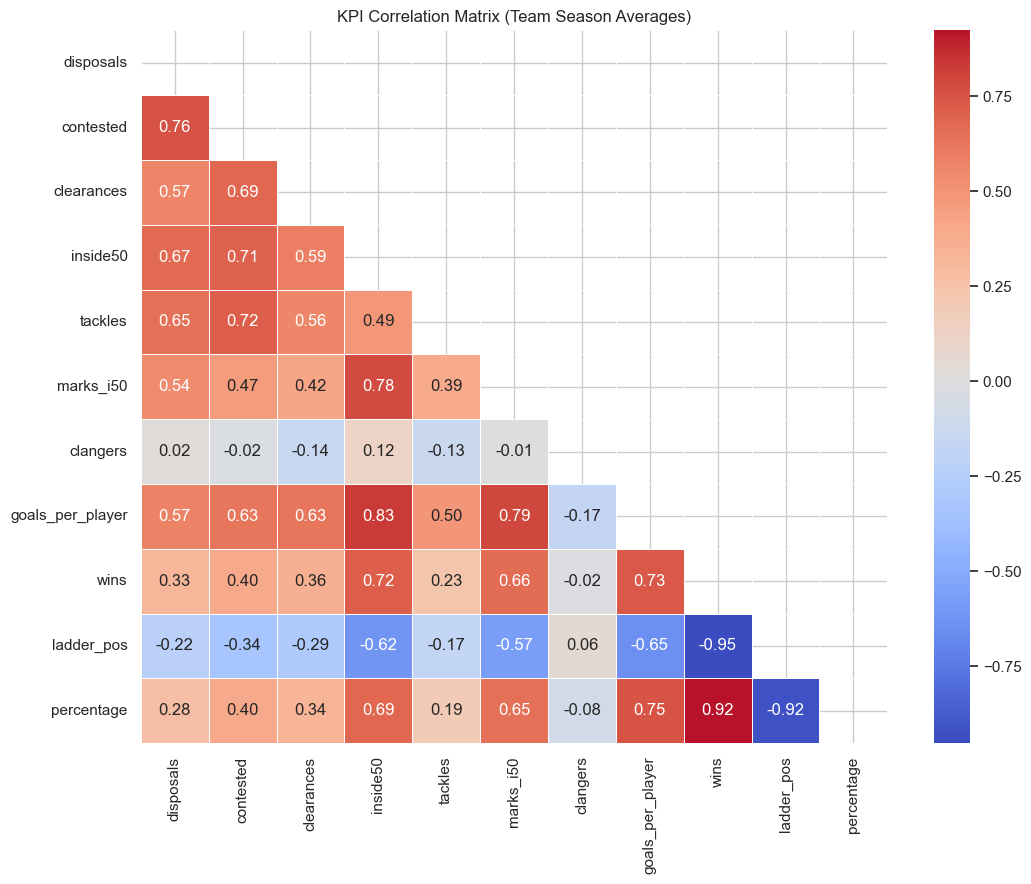

In [4]:
# Full correlation heatmap (KPIs + outcomes)
analysis_cols = kpi_cols + ['wins', 'ladder_pos', 'percentage']
corr_matrix = df[analysis_cols].corr()

# Rename for readability
rename = {c: c.replace('avg_','') for c in kpi_cols}
corr_matrix = corr_matrix.rename(columns=rename, index=rename)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax, linewidths=0.5)
ax.set_title('KPI Correlation Matrix (Team Season Averages)')
plt.tight_layout()
plt.show()

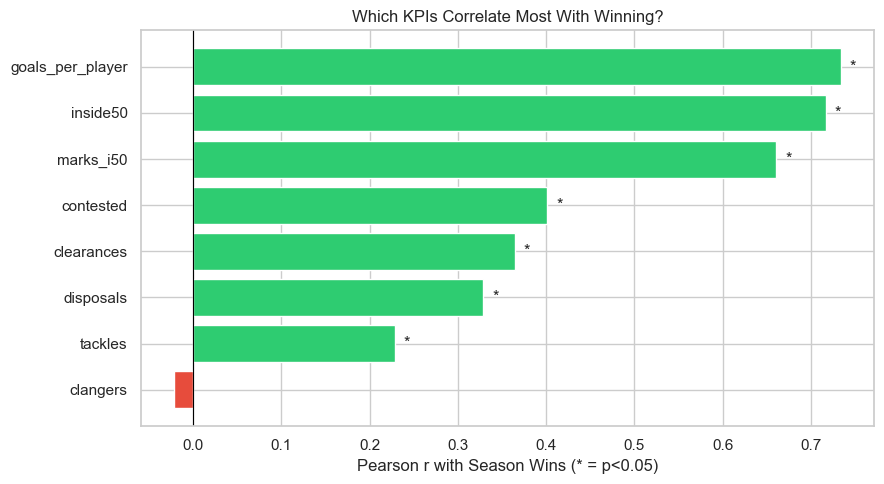

In [5]:
# Bar chart: correlation with wins
corr_df_sorted = corr_df.sort_values('r')
colours = ['#e74c3c' if r < 0 else '#2ecc71' for r in corr_df_sorted['r']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(corr_df_sorted['kpi'], corr_df_sorted['r'], color=colours)
ax.axvline(0, color='black', lw=0.8)
for bar, sig in zip(bars, corr_df_sorted['significant']):
    if sig:
        ax.text(bar.get_width() + 0.01 if bar.get_width() >= 0 else bar.get_width() - 0.01,
                bar.get_y() + bar.get_height()/2, '*',
                va='center', ha='left' if bar.get_width() >= 0 else 'right', fontsize=12)
ax.set_xlabel('Pearson r with Season Wins (* = p<0.05)')
ax.set_title('Which KPIs Correlate Most With Winning?')
plt.tight_layout()
plt.show()

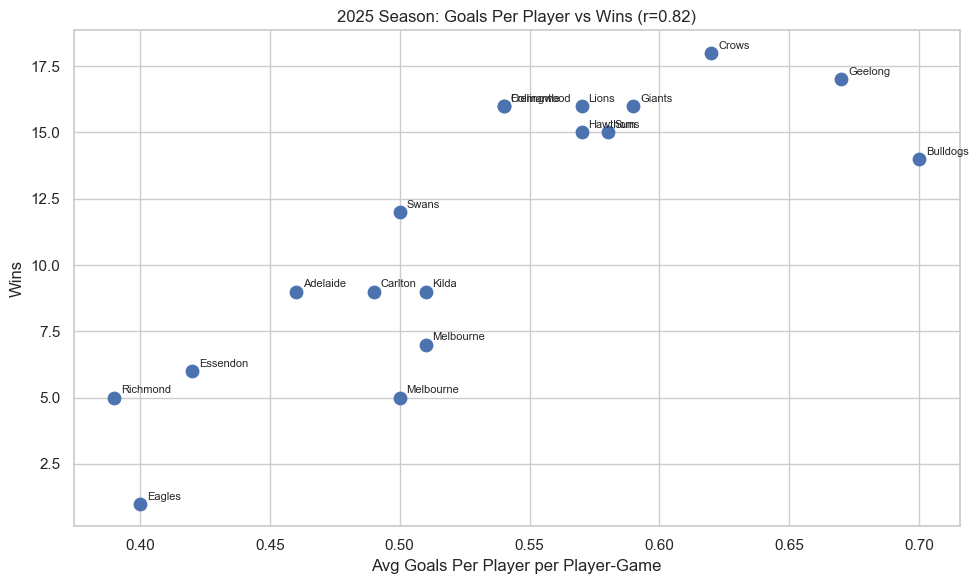

In [6]:
# Scatter: top correlated KPI vs wins with team labels for latest season
top_kpi = corr_df.iloc[0]['kpi']
latest = df[df.year == df.year.max()].copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(latest[f'avg_{top_kpi}'], latest['wins'], s=80, zorder=3)
for _, row in latest.iterrows():
    ax.annotate(row['team_name'].split()[-1],
                (row[f'avg_{top_kpi}'], row['wins']),
                textcoords='offset points', xytext=(5, 3), fontsize=8)
r, p = stats.pearsonr(latest[f'avg_{top_kpi}'], latest['wins'])
ax.set_xlabel(f'Avg {top_kpi.replace("_"," ").title()} per Player-Game')
ax.set_ylabel('Wins')
ax.set_title(f'{latest.year.iloc[0]} Season: {top_kpi.replace("_"," ").title()} vs Wins (r={r:.2f})')
plt.tight_layout()
plt.show()

conn.close()